### Задание:
**Задача 1**
Изучите таблицу users_info, содержащую информацию о пользователях. Проведите разведочный анализ данных:

**Общая информация о таблице**
+ Сколько в таблице строк и столбцов?
+ Какие типы данных у каждого столбца?

**Пропущенные значения**
+Сколько пропущенных значений в каждом столбце?
+ Удалите все строки с пропущенными значениями. Какой процент данных был удалён?

**Выбросы по возрасту**
+ Рассчитайте границы для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
+ Удалите выбросы из таблицы.

**Визуализация**
+ Постройте гистограмму (sns.histplot) распределения возрастов пользователей.



**Задача 2**
Проанализируйте распределение пользователей по полу и городам:
+ Рассчитайте количество пользователей по каждому полу и городу с помощью группировки и агрегации.

+ Используйте pivot_table, чтобы представить данные:
— города в строках,
— пол в столбцах.
+ Для каждого города рассчитайте долю женщин среди всех пользователей.
+ Постройте столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?

**Задача 3** Сегментация

Загрузите таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.

Рассчитайте среднее количество тренировок в месяц для каждого пользователя.

**Подсказка:** для создания групп используйте функцию cut из библиотеки pandas. Cut используется для деления числового столбца DataFrame на интервалы.
+ Разделите пользователей на три группы по уровню активности:

— мало (редко тренируются),

— средне,

— много (тренируются часто).

+ Посчитайте, сколько пользователей входит в каждую из этих групп.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
path = '/content/drive/MyDrive/ТЗ2Питон/users_info.csv'
users = pd.read_csv(path)
users.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### Задача 1. EDA

In [8]:
#Сколько в таблице строк и столбцов?
users.shape

(1000, 4)

In [9]:
#Какие типы данных у каждого столбца?
users.dtypes

,0
id_user,int64
city,object
age,float64
gender,object


In [10]:
#Сколько пропущенных значений в каждом столбце?
users.isnull().sum()

,0
id_user,0
city,0
age,88
gender,89


In [11]:
#Удалите все строки с пропущенными значениями. Какой процент данных был удалён?
users = users[~users['age'].isnull()]
users = users[~users['gender'].isnull()]
users.isnull().sum()
#17.7% даных удалено из таблицы

,0
id_user,0
city,0
age,0
gender,0


In [12]:
#Рассчитайте границы для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
users['age'].describe()

,age
count,865.000000
mean,39.419653
std,13.774501
min,18.000000
25%,28.000000
50%,37.000000
75%,51.000000
max,65.000000


In [13]:
users['gender'].value_counts()

,count
gender,
female,451
male,414


In [14]:
users['city'].value_counts()

,count
city,
Москва,325
СПб,277
Екатеринбург,133
Казань,130


<Axes: ylabel='age'>

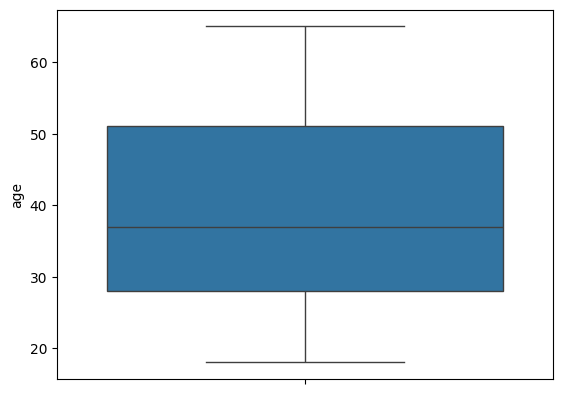

In [15]:
sns.boxplot(users['age'])

In [16]:
Q1 = np.percentile(users['age'], 25)
Q3 = np.percentile(users['age'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

-6.5
85.5


In [17]:
#Удалите выбросы из таблицы.
users_clean = users.loc[users['age']< upper_bound].copy()
users_clean.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female


In [18]:
users_clean.shape

(865, 4)

<Axes: xlabel='age', ylabel='Count'>

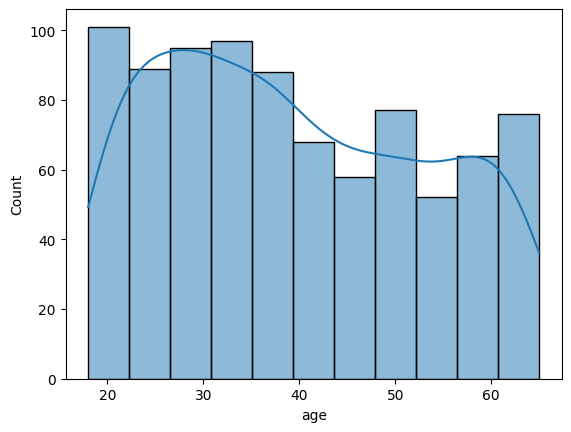

In [19]:
#Визуализация. Постройте гистограмму (sns.histplot) распределения возрастов пользователей.
sns.histplot(users_clean['age'], kde=True)

### Задача 2. Доля пользователей-женщин по городам

In [20]:
#Рассчитайте количество пользователей по каждому полу и городу с помощью группировки и агрегации.
#p_gr = pivot_pay.groupby('mon')[['cnt_group', 'cnt_indiv', 'cnt_total', 'sum_group', 'sum_indiv', 'sum_total']].\
#sum().reset_index()
cnt_users = users_clean.groupby(['gender','city']).size().reset_index(name='user_count')
cnt_users

,gender,city,user_count
0,female,Екатеринбург,55
1,female,Казань,53
2,female,Москва,220
3,female,СПб,123
4,male,Екатеринбург,78
5,male,Казань,77
6,male,Москва,105
7,male,СПб,154


In [21]:
#Используйте pivot_table, чтобы представить данные: — города в строках, — пол в столбцах.
pivot_users = pd.pivot_table(cnt_users,\
                           values='user_count',\
                           index=['city'],\
                           columns='gender',\
                           aggfunc=['sum'],\
                           fill_value=0).reset_index()
pivot_users.head()

city    sum     
gender               female male
0       Екатеринбург     55   78
1             Казань     53   77
2             Москва    220  105
3                СПб    123  154

In [22]:
#Для каждого города рассчитайте долю женщин среди всех пользователей.
# 1. Считаем общее количество пользователей (Мужчины + Женщины)
total_users = pivot_users[('sum', 'female' )] + pivot_users[('sum', 'male')]

# 2. Рассчитываем долю женщин и записываем в новую колонку
pivot_users['female_share'] = pivot_users[('sum', 'female')] / total_users

# Выводим результат
pivot_users


city    sum      female_share
gender               female male             
0       Екатеринбург     55   78     0.413534
1             Казань     53   77     0.407692
2             Москва    220  105     0.676923
3                СПб    123  154     0.444043

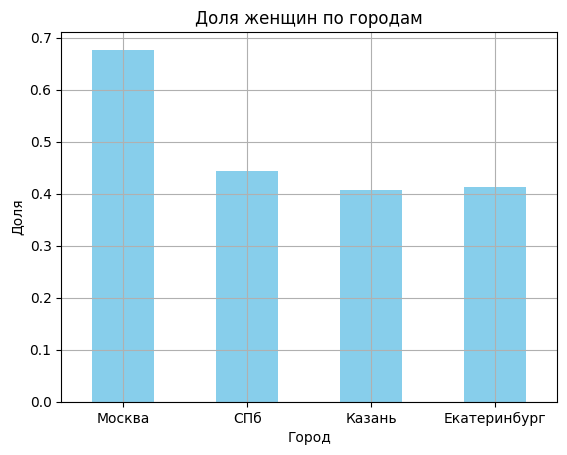

In [33]:
#города и доля женщин
data = {"city": ["Москва", "СПб", "Казань","Екатеринбург"], "female_share": [0.676923, 0.444043, 0.407692,0.413534]}
df = pd.DataFrame(data)
# Строим график
df.plot(kind="bar", x="city", y="female_share", color="skyblue", legend=False)
# Настраиваем подписи
plt.title("Доля женщин по городам")
plt.xlabel("Город")
plt.ylabel("Доля")
plt.grid(True)
plt.ylim(bottom=0)
plt.xticks(rotation=0)

plt.show()

### Задача 3. Делим пользователей на бины

In [34]:
#Загрузите таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.
path = '/content/drive/MyDrive/ТЗ2Питон/payments_monthly.csv'
payments_monthly = pd.read_csv(path)
payments_monthly.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [58]:
#Рассчитайте среднее количество тренировок в месяц для каждого пользователя.
#Подсказка: для создания групп используйте функцию cut из библиотеки pandas. Cut используется для деления числового столбца DataFrame на интервалы.
#Разделите пользователей на три группы по уровню активности:
#— мало (редко тренируются),
#— средне,
#— много (тренируются часто).
#Посчитайте, сколько пользователей входит в каждую из этих групп.

avg_cnt_work = payments_monthly.groupby('id_user')[['cnt_total']].sum().reset_index().rename(columns = {'cnt_total':'cnt_train'})
avg_cnt_work_mon = payments_monthly.groupby('id_user')[['cnt_total']].count().reset_index().rename(columns = {'cnt_total':'cnt_mon'})
total_cnt_work = avg_cnt_work.merge(avg_cnt_work_mon, on = 'id_user', how = 'inner')
total_cnt_work


,id_user,cnt_train,cnt_mon
0,1000,33,9
1,1001,129,11
2,1002,128,11
3,1003,31,6
4,1004,18,9
...,...,...,...
964,1994,7,1
965,1995,23,2
966,1996,3,2
967,1997,45,9


In [61]:
total_cnt_work['avg_cnt_train'] = round((total_cnt_work['cnt_train'])/(total_cnt_work['cnt_mon']),0)
total_cnt_work

,id_user,cnt_train,cnt_mon,avg_cnt_train
0,1000,33,9,4.0
1,1001,129,11,12.0
2,1002,128,11,12.0
3,1003,31,6,5.0
4,1004,18,9,2.0
...,...,...,...,...
964,1994,7,1,7.0
965,1995,23,2,12.0
966,1996,3,2,2.0
967,1997,45,9,5.0


In [62]:
print(total_cnt_work['avg_cnt_train'].max())

18.0


In [63]:
bins = [0, 9, 17, float('inf')]
labels = ['мало (редко тренируются)', 'средне', 'много (тренируются часто)']
total_cnt_work['group'] = pd.cut(total_cnt_work['avg_cnt_train'],\
                                       bins=bins, labels=labels, right=True)
total_cnt_work



,id_user,cnt_train,cnt_mon,avg_cnt_train,group
0,1000,33,9,4.0,мало (редко тренируются)
1,1001,129,11,12.0,средне
2,1002,128,11,12.0,средне
3,1003,31,6,5.0,мало (редко тренируются)
4,1004,18,9,2.0,мало (редко тренируются)
...,...,...,...,...,...
964,1994,7,1,7.0,мало (редко тренируются)
965,1995,23,2,12.0,средне
966,1996,3,2,2.0,мало (редко тренируются)
967,1997,45,9,5.0,мало (редко тренируются)


In [64]:
activity_cnt = total_cnt_work['group'].value_counts().sort_index()
activity_cnt

,count
group,
мало (редко тренируются),746
средне,220
много (тренируются часто),3
